In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.gridspec as gridspec

#
from Calculations_Functions import proportions_from_filename, metrics_table
from matplotlib.colors import ListedColormap
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [9]:
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)

In [3]:
filename= '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112018_run_365_days_full_release_export_kernels_added.zarr'

In [4]:
run_ratio = proportions_from_filename(filename = filename)

table_ratio  = metrics_table(filename = filename, plot = False)

In [5]:
water_ratio, sediment_ratio =  run_ratio['Sewage W.C.'] + run_ratio['Colloidal W.C.'] + run_ratio['Marine W.C.'] , run_ratio['Sewage S.'] + run_ratio['Colloidal S.'] + run_ratio['Marine S.']

In [6]:
data_ratio = xr.open_zarr(filename)
wc_ratio = data_ratio.where((data_ratio.status < 4)& (data_ratio.status > 0))
sed_ratio = data_ratio.where((data_ratio.status > 10))

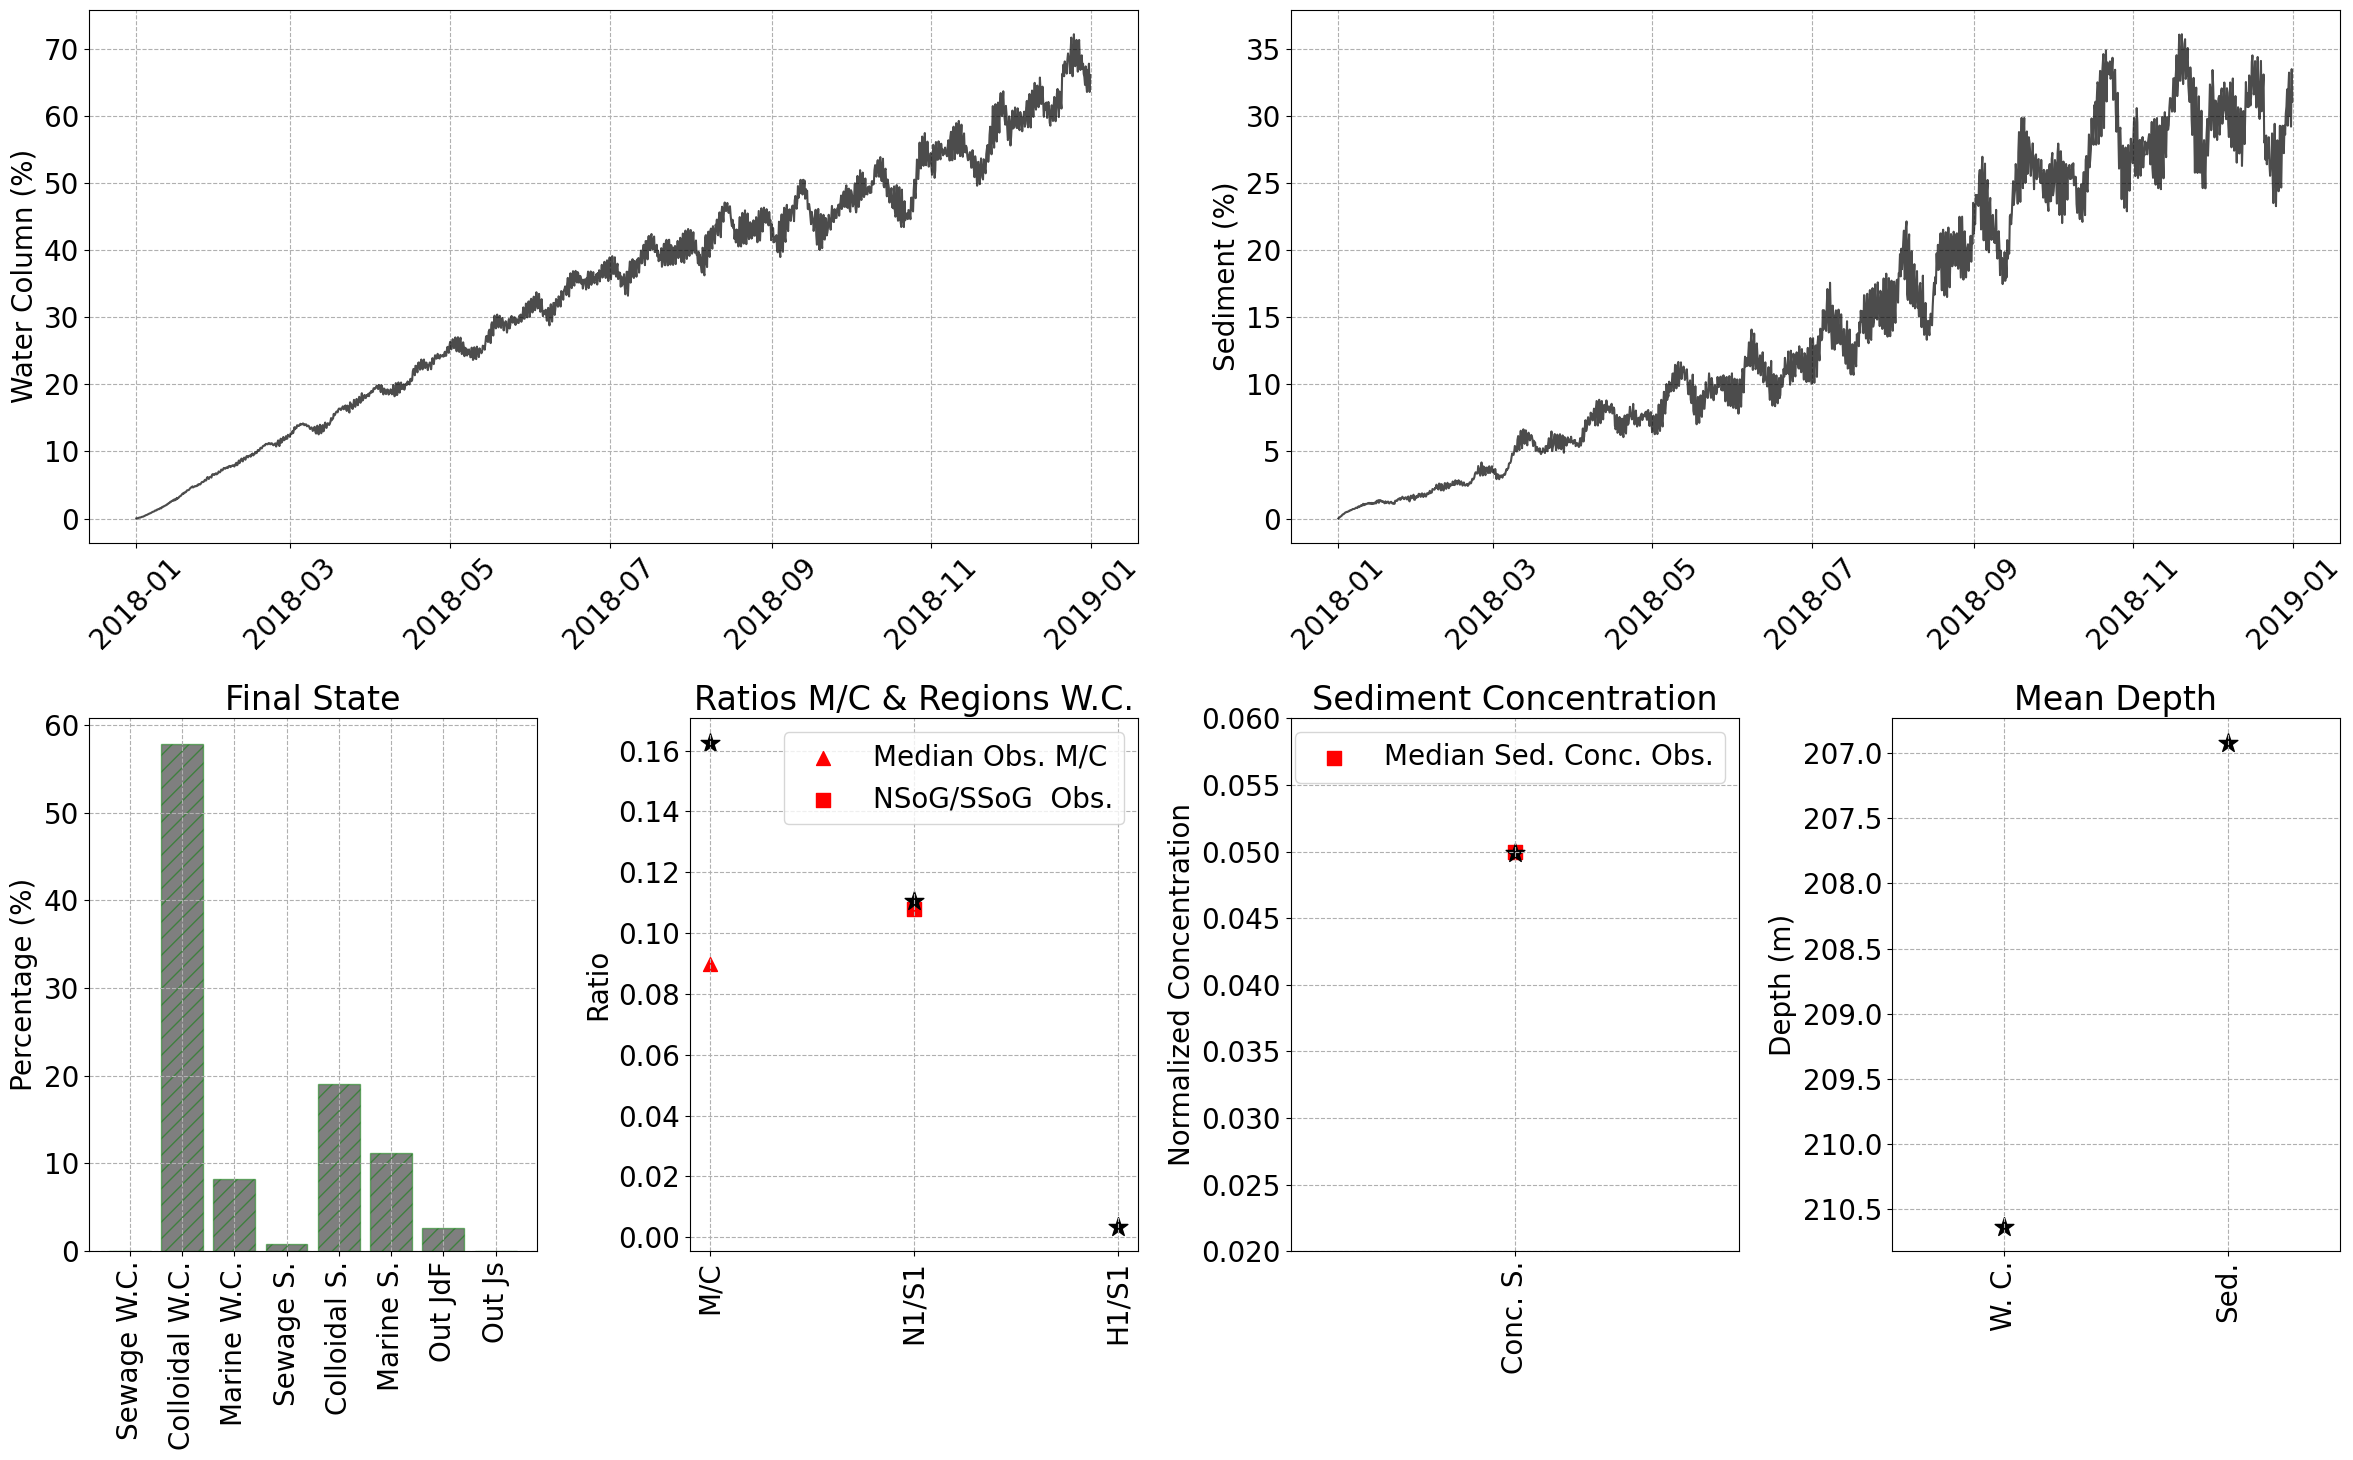

In [7]:
plt.rcParams.update({'font.size': 20})

fig = plt.figure(figsize=(24, 15))
gs = gridspec.GridSpec(2, 8, height_ratios=[1,1])

# === Top row (2 panels) ===
ax1 = fig.add_subplot(gs[0, 0:4])
ax2 = fig.add_subplot(gs[0, 4:8])

# === Middle row (3 panels) ===
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])
ax6 = fig.add_subplot(gs[1, 6:8])
# --- Top left plot (Water Column) ---
ax1.plot(water_ratio, 'k', alpha=.7)
ax1.grid(linestyle='--')
ax1.set_ylabel('Water Column (%)')
ax1.tick_params(axis='x', rotation=45)

# --- Top right plot (Sediment) ---
ax2.plot(sediment_ratio, 'k', alpha=.7)
ax2.grid(linestyle='--')
ax2.set_ylabel('Sediment (%)')
ax2.tick_params(axis='x', rotation=45)

# --- Middle plots ---
# Middle left
ax3.bar(run_ratio.columns[1:], run_ratio.iloc[-1][1:].values, color='k', alpha = .5, hatch = '//', edgecolor = 'g')

#ax3.plot(run_ratio.columns[1:], run_ratio.iloc[-1][1:].values, color='k', alpha = .5)
ax3.grid(linestyle='--')
ax3.tick_params(axis='x', rotation=90)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Final State')

# Middle center
ax4.scatter(table_ratio.columns[1], 0.09, c='r', marker = '^', s = 100, label = 'Median Obs. M/C')
ax4.scatter(table_ratio.columns[3], 0.108, c='r', marker = 's', s = 100, label = 'NSoG/SSoG  Obs.')
ax4.scatter(table_ratio.columns[[1,3,4]], table_ratio.loc[0].values[[1,3,4]], marker = '*', color='k', s=200)

ax4.grid(linestyle='--')
ax4.tick_params(axis='x', rotation=90)
ax4.legend()
ax4.set_ylabel('Ratio')
ax4.set_title('Ratios M/C & Regions W.C.')

#
ax5.scatter(table_ratio.columns[2], 0.05, c='r', marker = 's', s = 100, label = 'Median Sed. Conc. Obs.') # Median of normalized obs. concentrations
ax5.scatter(table_ratio.columns[2], table_ratio.loc[0].values[2], marker = '*', color='k', s=200)
ax5.grid(linestyle='--')
ax5.legend()
ax5.tick_params(axis='x', rotation=90)
ax5.set_ylabel('Normalized Concentration')
ax5.set_ylim([0.02, 0.06])
ax5.set_title('Sediment Concentration')


# Middle right
ax6.scatter(table_ratio.columns[-2:], table_ratio.loc[0].values[-2:], marker = '*', color='k', s=200)
ax6.grid(linestyle='--')
ax6.set_xlim([-.5, 1.5])
ax6.tick_params(axis='x', rotation=90)
ax6.invert_yaxis()
ax6.set_ylabel('Depth (m)')
ax6.set_title('Mean Depth')

#
#
plt.tight_layout()

plt.show()



In [10]:
run_ratio.iloc[-1][1:]

Sewage W.C.        0.008562
Colloidal W.C.    57.865297
Marine W.C.        8.279110
Sewage S.          0.790525
Colloidal S.      19.055365
Marine S.         11.232877
Out JdF            2.651256
Out Js             0.048516
Name: 2018-12-31 18:30:00, dtype: float64

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [7]:
def proportions(data):
    colloidal_water = []
    marine_water = [] 
    sewage_water = []
    initial = []
    colloidal_sediment = []
    marine_sediment = []
    sewage_sediment = []
    particles_out_jdf = []
    particles_out_js = []
    total = []

    for i in range(len(data.obs)):
        status_i = data.status[:, i].values
        lat_i = data.lat[:, i].values
        lon_i = data.lon[:, i].values

        # Mask to keep only rows without NaNs
        valid_mask = (
            np.isfinite(status_i) &
            np.isfinite(lat_i) &
            np.isfinite(lon_i)
        )
        status_i = status_i[valid_mask]
        lat_i = lat_i[valid_mask]
        lon_i = lon_i[valid_mask]

        # Total valid particles
        len_T = len(status_i)

        if len_T == 0:
            # Append NaNs if no data for this time step
            initial.append(np.nan)
            colloidal_water.append(np.nan)
            marine_water.append(np.nan)
            sewage_water.append(np.nan)
            colloidal_sediment.append(np.nan)
            marine_sediment.append(np.nan)
            sewage_sediment.append(np.nan)
            particles_out_jdf.append(np.nan)
            particles_out_js.append(np.nan)
            total.append(0)
            continue

        # Counts by status
        len_initial = np.count_nonzero(status_i < 0)
        len_1 = np.count_nonzero(status_i == 1)
        len_2 = np.count_nonzero(status_i == 2)
        len_3 = np.count_nonzero(status_i == 3)
        len_11 = np.count_nonzero(status_i == 11)
        len_12 = np.count_nonzero(status_i == 12)
        len_13 = np.count_nonzero(status_i == 13)

        # Location counts
        len_jdf = np.count_nonzero(status_i == 7)
        len_js = np.count_nonzero(status_i == 8)

        # Append results
        initial.append(len_initial)
        colloidal_water.append(len_2)
        marine_water.append(len_3) 
        sewage_water.append(len_1)
        colloidal_sediment.append(len_12)
        marine_sediment.append(len_13)
        sewage_sediment.append(len_11)
        particles_out_jdf.append(len_jdf)
        particles_out_js.append(len_js)    
        total.append(len_T)

    total_arr = np.array(total, dtype=float)

    # Avoid divide-by-zero: will give NaN where total_arr == 0
    proportion_initial = np.array(initial, dtype=float) / total_arr
    p_colloidal_water = np.array(colloidal_water, dtype=float) / total_arr
    p_marine_water = np.array(marine_water, dtype=float) / total_arr
    p_sewage_water = np.array(sewage_water, dtype=float) / total_arr
    p_colloidal_sediment = np.array(colloidal_sediment, dtype=float) / total_arr
    p_marine_sediment = np.array(marine_sediment, dtype=float) / total_arr
    p_sewage_sediment = np.array(sewage_sediment, dtype=float) / total_arr
    p_out_jdf = np.array(particles_out_jdf, dtype=float) / total_arr
    p_out_js = np.array(particles_out_js, dtype=float) / total_arr

    data_array = np.column_stack([
        proportion_initial * 100,
        p_colloidal_water * 100,
        p_marine_water * 100,
        p_sewage_water * 100,
        p_colloidal_sediment * 100,
        p_marine_sediment * 100,
        p_sewage_sediment * 100,
        p_out_jdf * 100,
        p_out_js * 100,
        total_arr
    ])

    data_proportions = pd.DataFrame(
        data=data_array,
        columns=[
            'initial',
            'colloidal_water',
            'marine_water',
            'sewage_water',
            'colloidal_sediment',
            'marine_sediment',
            'sewage_sediment',
            'out_jdf',
            'out_js',
            'total_len'
        ]
    )

    return data_proportions

# Interannual comparison

In [2]:
data2018 = xr.open_zarr('/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112018_run_365_days_full_release_export_kernels_added.zarr')
data2022 = xr.open_zarr('/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_365_days_full_release_run_tau_0_01_ratio_0_2_sv_5_AD_0_052.zarr')

In [8]:
P_2018 = proportions(data2018); P_2022 = proportions(data2022) 

In [31]:
p2018_water = P_2018['sewage_water'] + P_2018['colloidal_water'] + P_2018['marine_water']
p2018_sediment = P_2018['sewage_sediment'] + P_2018['colloidal_sediment'] + P_2018['marine_sediment']
#
p2022_water = P_2022['sewage_water'] + P_2022['colloidal_water'] + P_2022['marine_water']
p2022_sediment = P_2022['sewage_sediment'] + P_2022['colloidal_sediment'] + P_2022['marine_sediment']

In [49]:
P_2018['out_jdf'] + P_2018['out_js']

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
1455    2.688356
1456    2.694064
1457    2.696918
1458    2.699772
1459    2.699772
Length: 1460, dtype: float64

In [45]:
print('2018 water', p2018_water.iloc[-1])
print('2018 sediment', p2018_sediment.iloc[-1])
print('2022 water', p2022_water.iloc[-1])
print('2022 sediment', p2022_sediment.iloc[-1])

2018 water 66.15296803652969
2018 sediment 31.078767123287673
2022 water 61.40280561122245
2022 sediment 35.35070140280561


/tmp/ipykernel_2649325/4107584695.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(mask['nav_lon'], mask['nav_lat'], mask['tmask'][0][0], cmap = cmap)


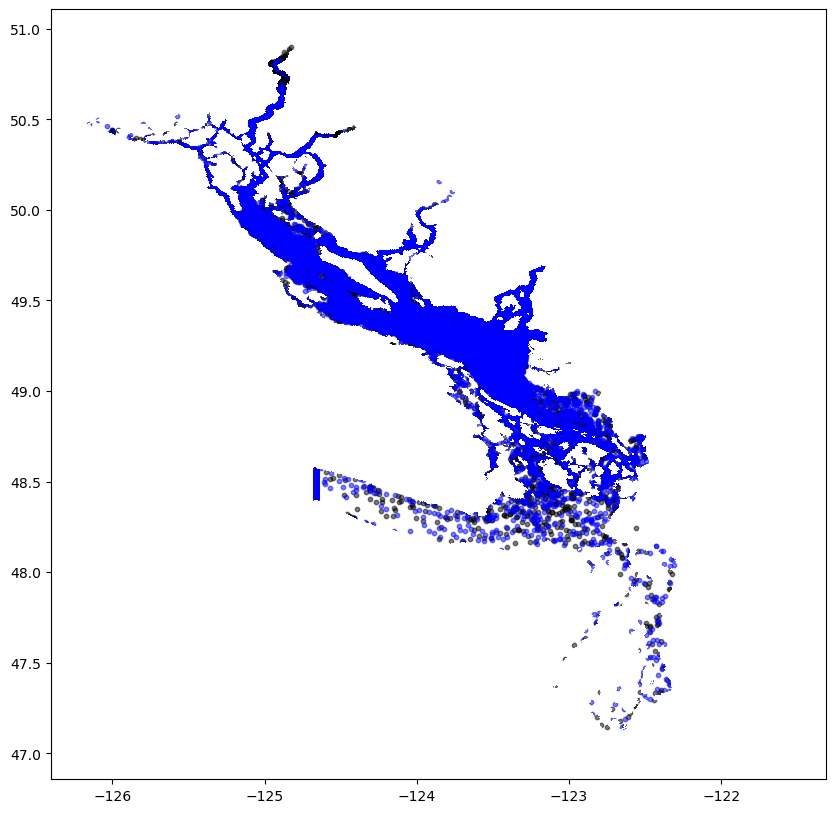

In [42]:
colors = [(1, 1, 1, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)
fig, ax = plt.subplots(figsize = (10,10))
ax.scatter(data2018['lon'][:,-1], data2018['lat'][:,-1], s = 10, c = 'k', alpha = .5)
ax.scatter(data2022['lon'][:,-1], data2022['lat'][:,-1], s = 10, c = 'b', alpha = .5)
ax.pcolormesh(mask['nav_lon'], mask['nav_lat'], mask['tmask'][0][0], cmap = cmap)

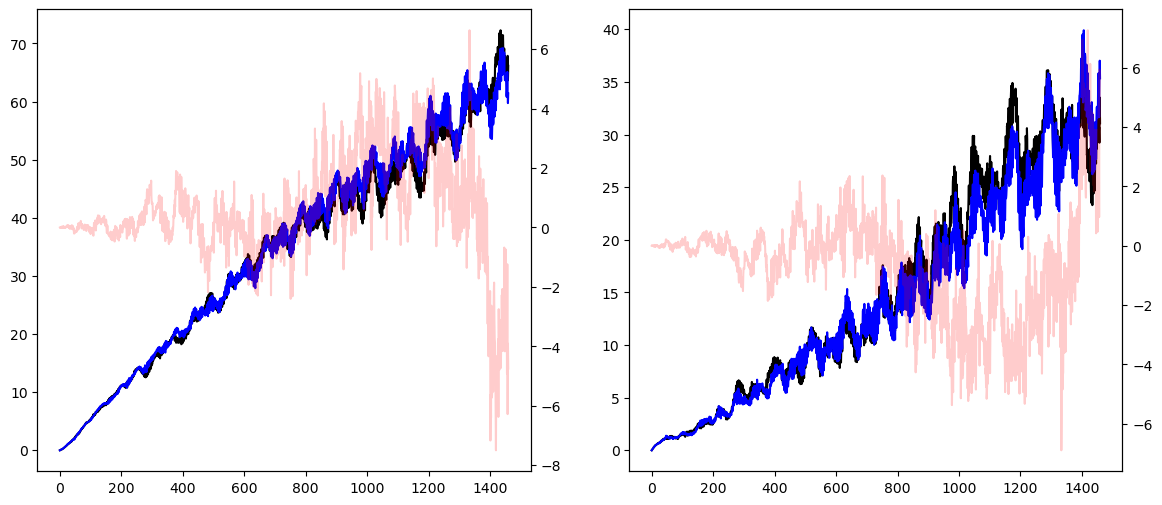

In [6]:
fig, ax = plt.subplots(1,2,figsize = (14,6))
ax[0].plot(p2018_water, 'k'); ax[0].plot(p2022_water, 'b')
axis = ax[0].twinx()
axis.plot(p2022_water - p2018_water, 'r', alpha = .2)
#
ax[1].plot(p2018_sediment, 'k'); ax[1].plot(p2022_sediment, 'b')
axis = ax[1].twinx()
axis.plot(p2022_sediment - p2018_sediment, 'r', alpha = .2)

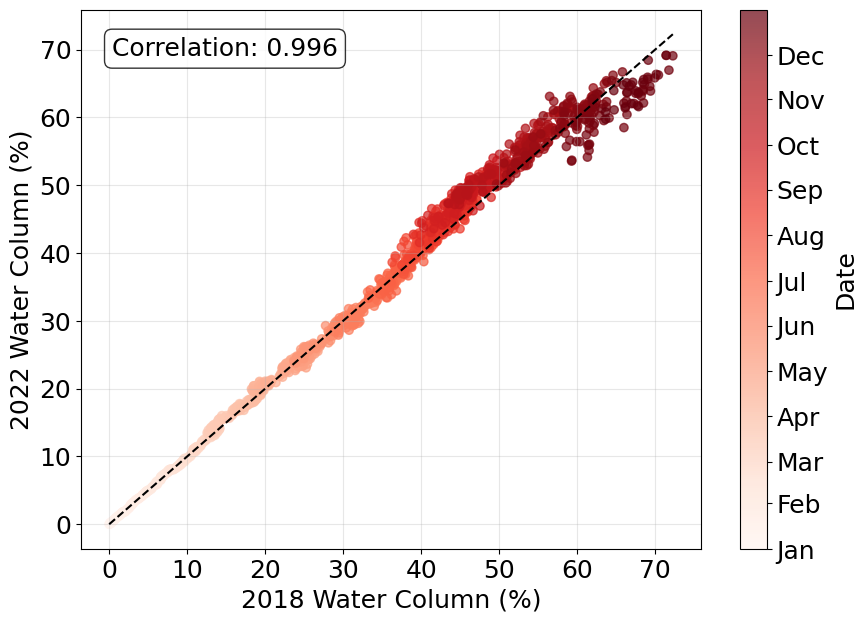

In [7]:
# Generate synthetic data
dt = pd.date_range(start='2018-01-01', end='2018-12-31 18:00:00', freq='6h')


# 1. Calculate Correlation
correlation = p2018_water.corr(p2022_water)

# 2. Plotting
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10, 7))

# Create scatter plot
# We use np.arange(len(dt)) for 'c' to map colors linearly to the sequence of data
sc = plt.scatter(p2018_water, p2022_water, c=np.arange(len(dt)), cmap='Reds', alpha=0.7)

# Add 1:1 line
limit_min = min(p2018_water.min(), p2022_water.min())
limit_max = max(p2018_water.max(), p2022_water.max())
plt.plot([limit_min, limit_max], [limit_min, limit_max], 'k--', label='1:1 Line')

# Add text with correlation
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=18,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Configure Colorbar with custom ticks
cbar = plt.colorbar(sc)
cbar.set_label('Date')

# Select ticks (e.g., start of each month to avoid clutter)
# 'freq="MS"' gives Month Start
tick_dates = pd.date_range(start='2018-01-01', end='2018-12-31', freq='MS')

# Find corresponding indices for these dates
tick_locs = [dt.get_loc(d) for d in tick_dates if d in dt]
# Or using searchsorted if exact match might fail (though with MS and 6H starting Jan 1, it should match)
if not tick_locs:
    # Fallback if indices aren't exact
    tick_locs = dt.searchsorted(tick_dates)

tick_labels = tick_dates.strftime('%b')

cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels)

# Labels and Title
plt.xlabel('2018 Water Column (%)')
plt.ylabel('2022 Water Column (%)')
plt.grid(True, alpha=0.3)

Same plot than above, but with the two years

In [ ]:
filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112018_run_365_days_full_release_export_kernels_added.zarr'
filename2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_365_days_full_release_run_tau_0_01_ratio_0_2_sv_5_AD_0_052.zarr'

In [ ]:
run_2018 = proportions_from_filename(filename = filename1)
run_2022 = proportions_from_filename(filename = filename2)
#
table_2018  = metrics_table(filename = filename1, plot = False)
table_2022  = metrics_table(filename = filename2, plot = False)
#
water_2018, sediment_2018 =  run_2018['Sewage W.C.'] + run_2018['Colloidal W.C.'] + run_2018['Marine W.C.'] , run_2018['Sewage S.'] + run_2018['Colloidal S.'] + run_2018['Marine S.']
water_2022, sediment_2022 =  run_2022['Sewage W.C.'] + run_2022['Colloidal W.C.'] + run_2022['Marine W.C.'] , run_2022['Sewage S.'] + run_2022['Colloidal S.'] + run_2022['Marine S.']

In [14]:
dt = pd.date_range(start='2018-01-01', end='2018-12-31 18:00:00', freq='6H')
month_day = dt.strftime('%b %d')


/tmp/ipykernel_526156/3340243777.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dt = pd.date_range(start='2018-01-01', end='2018-12-31 18:00:00', freq='6H')


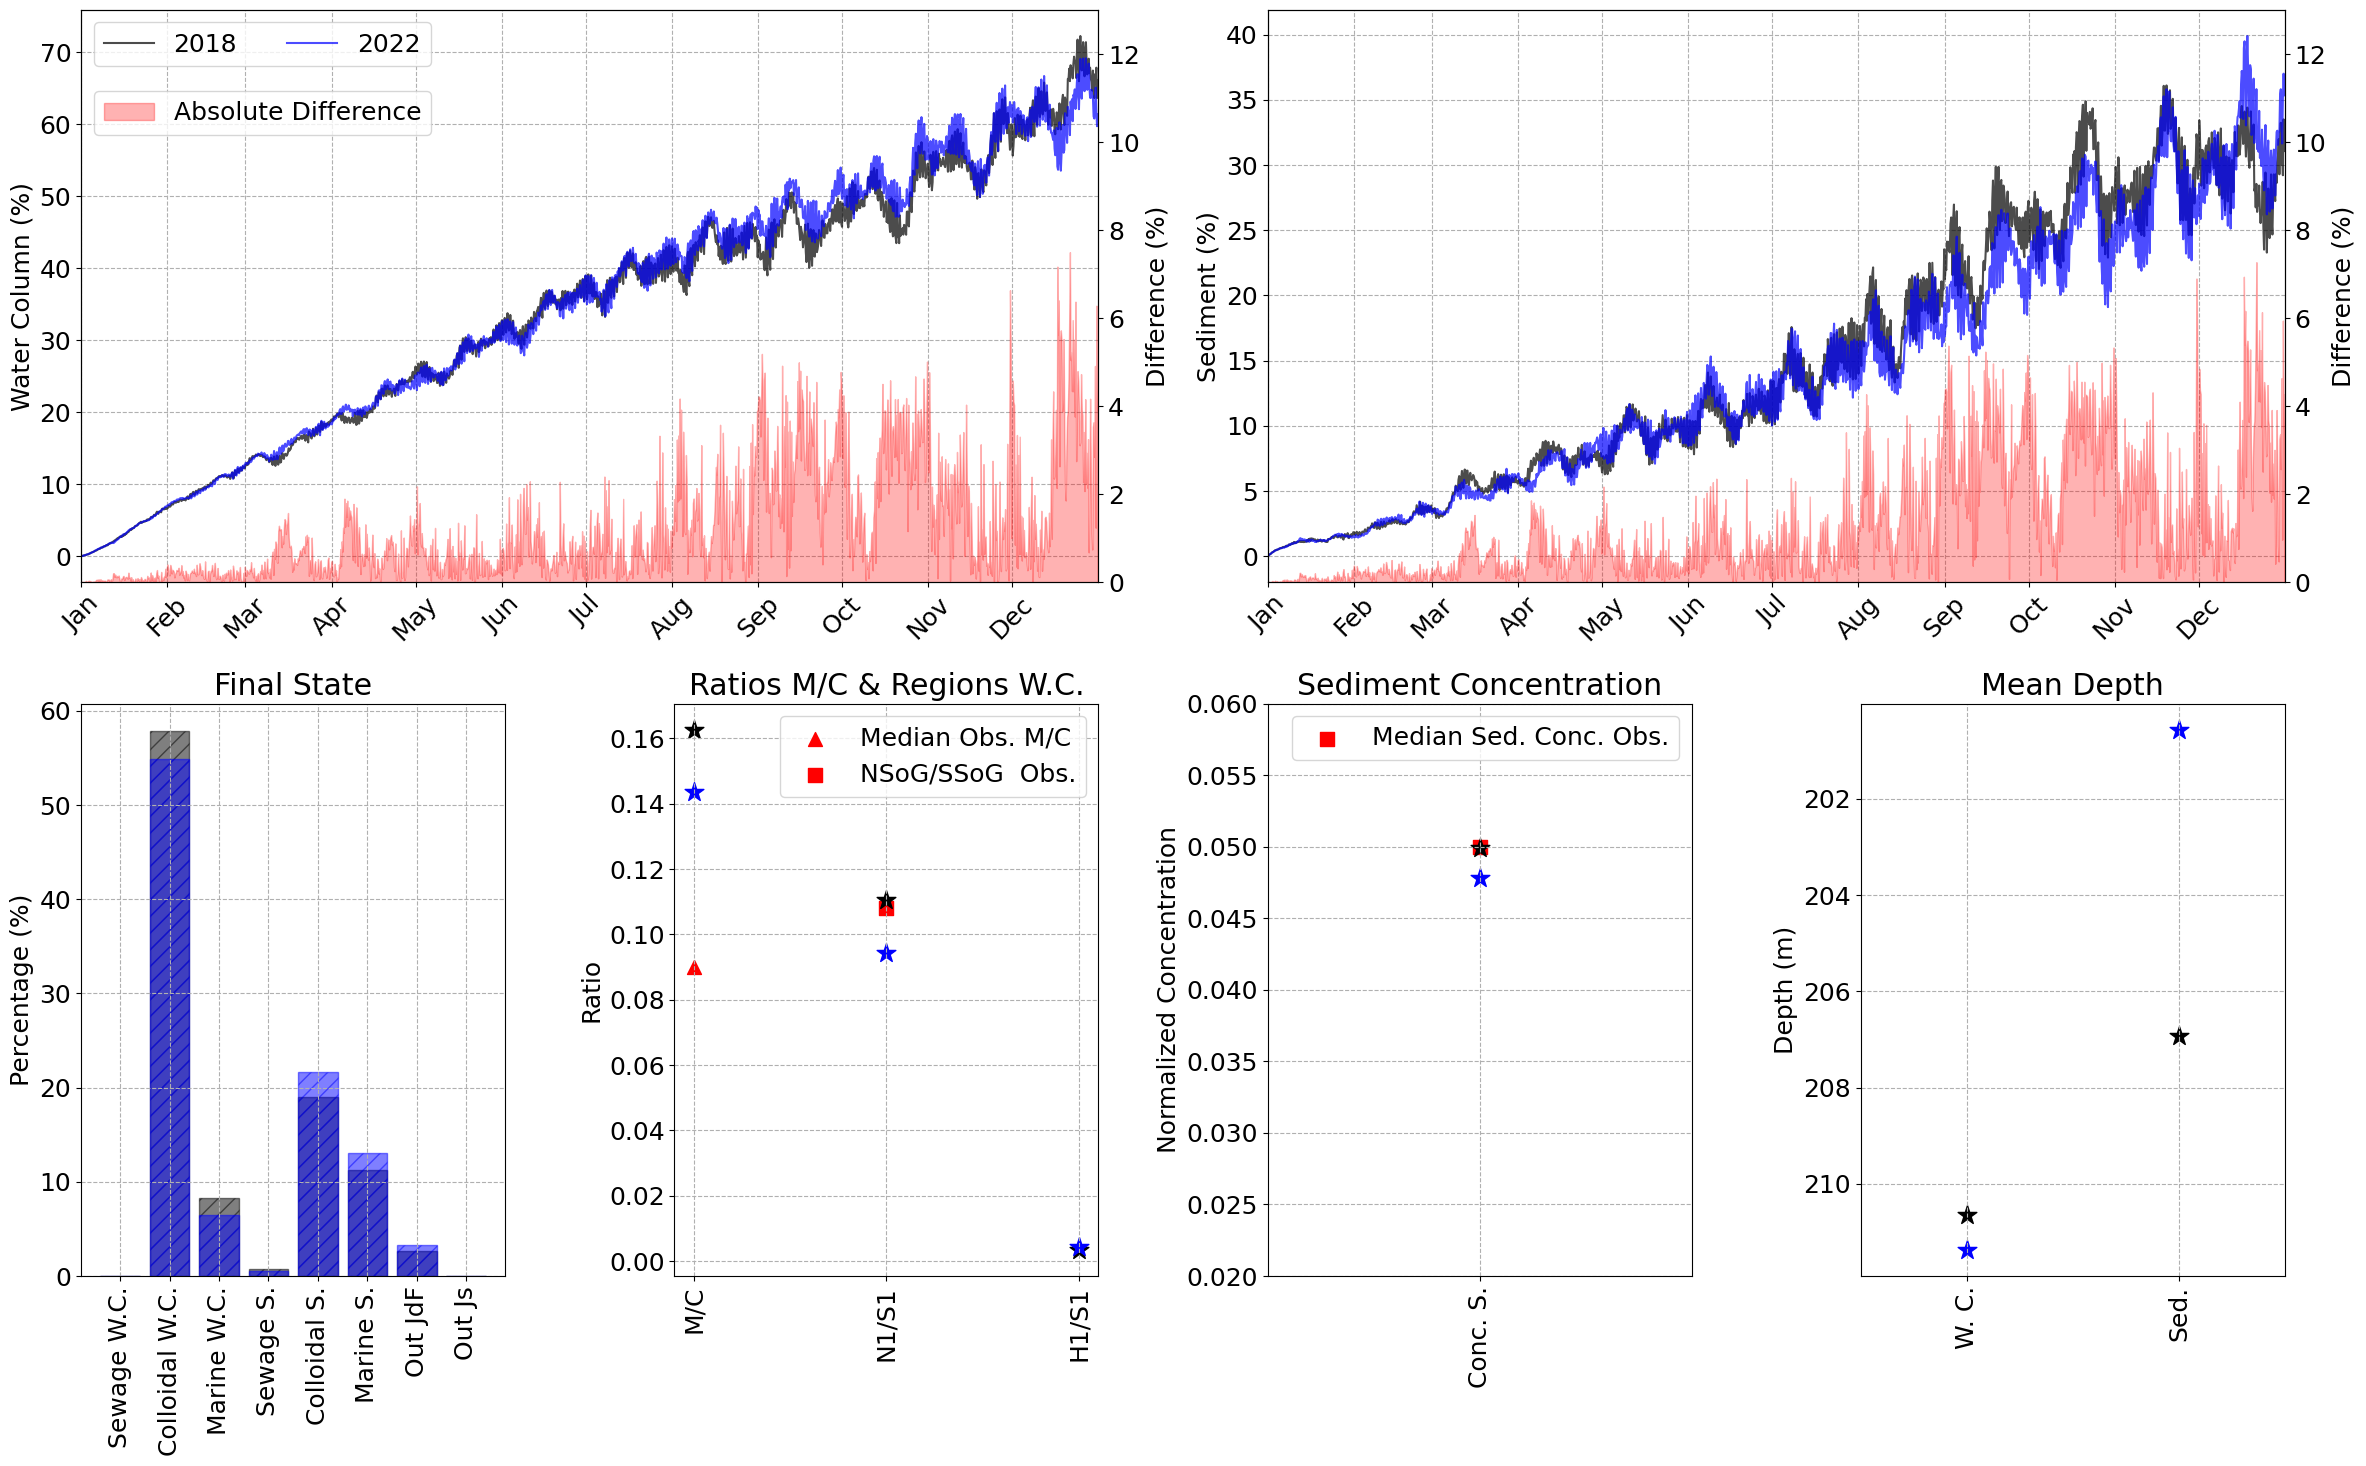

In [ ]:
plt.rcParams.update({'font.size': 18})

fig = plt.figure(figsize=(24, 15))
gs = gridspec.GridSpec(2, 8, height_ratios=[1,1])

# === Top row (2 panels) ===
ax1 = fig.add_subplot(gs[0, 0:4])
ax2 = fig.add_subplot(gs[0, 4:8])

# === Middle row (3 panels) ===
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])
ax6 = fig.add_subplot(gs[1, 6:8])
# --- Top left plot (Water Column) ---
tt = np.arange(0, len(water_2018))
#
ax1.plot(tt, water_2018, 'k', alpha=.7, label = '2018')
ax1.plot(tt, water_2022, 'b', alpha=.7, label = '2022')
axis1 = ax1.twinx()
axis1.fill_between(tt,0, np.abs(water_2022.values - water_2018.values), color = 'r', alpha = .3, label = 'Absolute Difference')
axis1.set_ylim(0,13)
axis1.set_ylabel('Difference (%)')
ax1.grid(linestyle='--')
ax1.set_ylabel('Water Column (%)')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc = 'upper left', ncol = 2); axis1.legend(loc = 'center left', bbox_to_anchor=(0, .82))
# --- Top right plot (Sediment) ---
ax2.plot(tt, sediment_2018, 'k', alpha=.7)
ax2.plot(tt, sediment_2022, 'b', alpha=.7)
axis2 = ax2.twinx()
axis2.fill_between(tt,0, np.abs(sediment_2022.values - sediment_2018.values), color = 'r', alpha = .3)
axis2.set_ylim(0,13)
axis2.set_ylabel('Difference (%)')
ax2.grid(linestyle='--')
ax2.set_ylabel('Sediment (%)')
ax2.tick_params(axis='x', rotation=45)

# --- Middle plots ---
# Middle left
ax3.bar(run_2018.columns[1:], run_2018.iloc[-1][1:].values, color='k', alpha = .5, hatch = '//', edgecolor = 'k')
ax3.bar(run_2022.columns[1:], run_2022.iloc[-1][1:].values, color='b', alpha = .5, hatch = '//', edgecolor = 'b')
#ax3.plot(run_ratio.columns[1:], run_ratio.iloc[-1][1:].values, color='k', alpha = .5)
ax3.grid(linestyle='--')
ax3.tick_params(axis='x', rotation=90)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Final State')

# Middle center
ax4.scatter(table_2018.columns[1], 0.09, c='r', marker = '^', s = 100, label = 'Median Obs. M/C')
ax4.scatter(table_2018.columns[3], 0.108, c='r', marker = 's', s = 100, label = 'NSoG/SSoG  Obs.')
ax4.scatter(table_2018.columns[[1,3,4]], table_2018.loc[0].values[[1,3,4]], marker = '*', color='k', s=200)
ax4.scatter(table_2022.columns[[1,3,4]], table_2022.loc[0].values[[1,3,4]], marker = '*', color='b', s=200)


ax4.grid(linestyle='--')
ax4.tick_params(axis='x', rotation=90)
ax4.legend()
ax4.set_ylabel('Ratio')
ax4.set_title('Ratios M/C & Regions W.C.')

#
ax5.scatter(table_2018.columns[2], 0.05, c='r', marker = 's', s = 100, label = 'Median Sed. Conc. Obs.') # Median of normalized obs. concentrations
ax5.scatter(table_2018.columns[2], table_2018.loc[0].values[2], marker = '*', color='k', s=200)
ax5.scatter(table_2022.columns[2], table_2022.loc[0].values[2], marker = '*', color='b', s=200)
ax5.grid(linestyle='--')
ax5.legend()
ax5.tick_params(axis='x', rotation=90)
ax5.set_ylabel('Normalized Concentration')
ax5.set_ylim([0.02, 0.06])
ax5.set_title('Sediment Concentration')


# Middle right
ax6.scatter(table_2018.columns[-2:], table_2018.loc[0].values[-2:], marker = '*', color='k', s=200)
ax6.scatter(table_2022.columns[-2:], table_2022.loc[0].values[-2:], marker = '*', color='b', s=200)
ax6.grid(linestyle='--')
ax6.set_xlim([-.5, 1.5])
ax6.tick_params(axis='x', rotation=90)
ax6.invert_yaxis()
ax6.set_ylabel('Depth (m)')
ax6.set_title('Mean Depth')
#
#
points_per_day = 4  
days_cumulative = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
#
tick_positions = [day * points_per_day for day in days_cumulative]
#
for ax in [ax1, ax2]: 
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(month_names, rotation=45) 
    ax.set_xlim(0, 1460) 
#
plt.tight_layout()
#
plt.show()